<a href="https://colab.research.google.com/github/Mariam759/INNOMATICS-GEN-AI-INTERNSHIP-2026/blob/main/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["DISABLE_TQDM"] = "1"

from transformers.utils import logging
logging.set_verbosity_error()

In [ ]:
!pip install transformers datasets scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

In [ ]:
dataset = load_dataset("imdb")

train_data = dataset['train']
test_data = dataset['test']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
def clean_text(example):
    text = example['text'].lower()
    return {"text": text}

train_data = train_data.map(clean_text)
test_data = test_data.map(clean_text)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
train_valid = train_data.train_test_split(test_size=0.2)

train_dataset = train_valid['train']
val_dataset = train_valid['test']

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])
val_dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])
test_data.set_format(type='torch', columns=['input_ids','attention_mask','label'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
!pip install --upgrade transformers

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs",
    do_train=True,
    do_eval=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.084558
1000,0.094276
1500,0.226452
2000,0.278030
2500,0.253607
3000,0.102608
3500,0.094042
4000,0.097265
4500,0.094756


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
500,0.084558
1000,0.094276
1500,0.226452
2000,0.278030
2500,0.253607
3000,0.102608
3500,0.094042
4000,0.097265
4500,0.094756
5000,0.090421


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.14160160369873045, metrics={'train_runtime': 4206.6653, 'train_samples_per_second': 9.509, 'train_steps_per_second': 1.189, 'total_flos': 1.05244422144e+16, 'train_loss': 0.14160160369873045, 'epoch': 2.0})

In [ ]:
predictions = trainer.predict(test_data)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94     12500
           1       0.93      0.95      0.94     12500

    accuracy                           0.94     25000
   macro avg       0.94      0.94      0.94     25000
weighted avg       0.94      0.94      0.94     25000



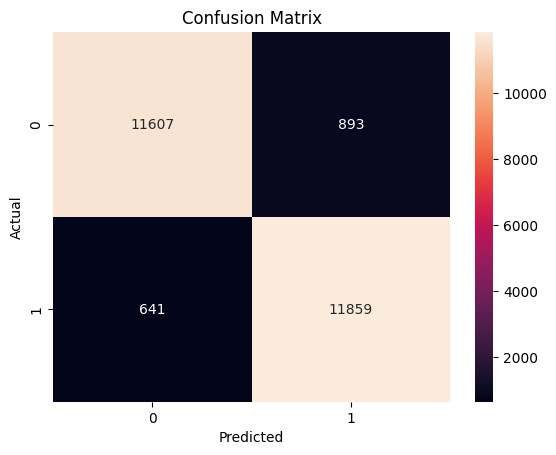

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# EXPERIMENTS

In [ ]:

# Freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

In [ ]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:


for param in model.bert.parameters():
    param.requires_grad = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.690644
1000,0.683677
1500,0.675852
2000,0.669236
2500,0.672357
3000,0.662267
3500,0.663599
4000,0.661096
4500,0.660495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
500,0.690644
1000,0.683677
1500,0.675852
2000,0.669236
2500,0.672357
3000,0.662267
3500,0.663599
4000,0.661096
4500,0.660495
5000,0.660316


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RuntimeError: on_train_begin must be called before on_evaluate

In [ ]:
predictions = trainer.predict(val_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)

results1 = {
    "accuracy": accuracy,
    "f1": f1,
    "precision": precision,
    "recall": recall
}

print("Frozen BERT Results:", results1)

Frozen BERT Results: {'accuracy': 0.9244, 'f1': 0.9257075471698113, 'precision': 0.9300947867298578, 'recall': 0.9213615023474179}


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model.bert.parameters():
    param.requires_grad = False

for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

trainer.train()
results2 = trainer.evaluate()
print("Last 2 Layers:", results2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.390469
1000,0.286112
1500,0.268978
2000,0.272765
2500,0.267968
3000,0.244871
3500,0.251576
4000,0.232813
4500,0.240986
5000,0.207502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Last 2 Layers: {'eval_loss': 0.25055113434791565, 'eval_accuracy': 0.9208, 'eval_f1': 0.9219858156028369, 'eval_precision': 0.9285714285714286, 'eval_recall': 0.9154929577464789, 'eval_runtime': 174.9558, 'eval_samples_per_second': 28.579, 'eval_steps_per_second': 3.572, 'epoch': 2.0}


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

trainer.train()
results3 = trainer.evaluate()
print("Full BERT:", results3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.250865
1000,0.229619
1500,0.237030
2000,0.245434
2500,0.236589
3000,0.206751


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full BERT: {'eval_loss': 0.2634570300579071, 'eval_accuracy': 0.925, 'eval_f1': 0.9261956307813423, 'eval_precision': 0.9318811881188119, 'eval_recall': 0.9205790297339593, 'eval_runtime': 174.1234, 'eval_samples_per_second': 28.715, 'eval_steps_per_second': 3.589, 'epoch': 2.0}


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

trainer.train()
results4 = trainer.evaluate()
print("DistilBERT:", results4)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.209466
1000,0.203977
1500,0.209085
2000,0.216641
2500,0.214887
3000,0.165982
3500,0.185069


...

Step,Training Loss
500,0.209466
1000,0.203977
1500,0.209085
2000,0.216641
2500,0.214887
3000,0.165982
3500,0.185069
4000,0.172217
4500,0.188639
5000,0.159113


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT: {'eval_loss': 0.28598475456237793, 'eval_accuracy': 0.9244, 'eval_f1': 0.9257075471698113, 'eval_precision': 0.9300947867298578, 'eval_recall': 0.9213615023474179, 'eval_runtime': 174.5892, 'eval_samples_per_second': 28.639, 'eval_steps_per_second': 3.58, 'epoch': 2.0}


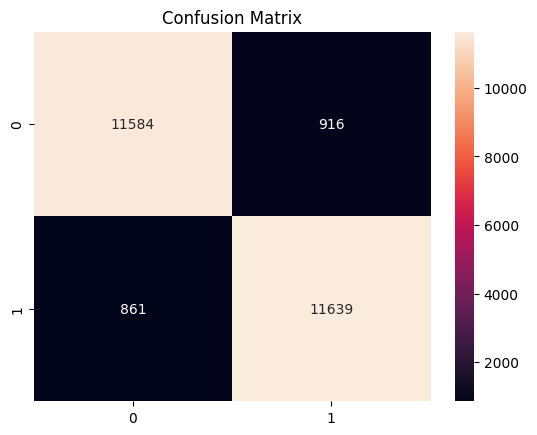

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_data)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [28]:
import pandas as pd

df = pd.DataFrame([
    {"Model": "Last 2 Layers", "Accuracy": results2['eval_accuracy'], "F1": results2['eval_f1']},
    {"Model": "Full BERT", "Accuracy": results3['eval_accuracy'], "F1": results3['eval_f1']},
    {"Model": "DistilBERT", "Accuracy": results4['eval_accuracy'], "F1": results4['eval_f1']}
])

df

,Model,Accuracy,F1
0,Last 2 Layers,0.9208,0.921986
1,Full BERT,0.9250,0.926196
2,DistilBERT,0.9244,0.925708


Detailed Analysis and Comparison

In this project, multiple experiments were conducted to understand how different fine-tuning strategies affect the performance of BERT-based models on sentiment classification.

All the models performed well, achieving accuracy above 92%, which shows that transformer-based models are highly effective for this task.

 Full BERT Fine-Tuning


The fully fine-tuned BERT model achieved the best performance among all experiments, with an accuracy of around 92.5% and an F1-score of 0.926.

This is because all the layers of the model were allowed to update during training, enabling it to learn dataset-specific features more effectively. However, this approach required more training time and computational resources.

🔹 Fine-Tuning Last 2 Layers

When only the last two layers of BERT were fine-tuned, the model achieved slightly lower performance, with an accuracy of around 92.0%.

This method allows partial learning, where only the deeper layers adapt to the dataset while earlier layers remain unchanged. It provides a good balance between performance and training efficiency, as it reduces computation time compared to full fine-tuning.

🔹 DistilBERT (Bonus Experiment)

DistilBERT achieved an accuracy of approximately 92.4%, which is very close to the performance of the full BERT model.

The main advantage of DistilBERT is that it is smaller and faster, as it has fewer parameters. Despite being lightweight, it maintains comparable performance, making it a practical choice when computational resources are limited.

-> Classification Performance

The classification report shows that the model performs well on both classes. The precision and recall values for both positive and negative sentiments are balanced, indicating that the model is not biased toward any particular class.

Most predictions are correct, and only a small number of misclassifications occur, mainly for ambiguous or borderline reviews.

->Comparison Summary

Overall, the experiments clearly show that:

Full fine-tuning provides the highest accuracy
Fine-tuning only the last layers reduces training time with a slight drop in performance
DistilBERT offers almost the same performance as BERT but is faster and more efficient
->Conclusion

From these experiments, it can be concluded that fine-tuning plays a crucial role in improving model performance. While full BERT fine-tuning gives the best results, DistilBERT serves as an excellent alternative due to its efficiency. Fine-tuning only a few layers can be useful when there are computational constraints.

In [33]:
import nbformat

nb = nbformat.read("Task4.ipynb", as_version=4)

# Remove widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, "clean_notebook.ipynb")